In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
include("../scripts/TesselationCore.jl")
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end


  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [2]:
using TetGen
using StaticArrays
using GLMakie
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots

import .TesselationCore


In [3]:
points3d = [TesselationCore.point3(@SVector rand(3)) for _ in 1:50]
coords, tets = TesselationCore.tesselate(points3d)
simplices = Vector([coords[:,tets[i,:]]' for i in 1:size(tets,1)])
simplex = simplices[1]


4×3 adjoint(::Matrix{Float64}) with eltype Float64:
 0.111769  0.102121   0.0724009
 0.144103  0.242249   0.0969119
 0.105358  0.10525    0.415203
 0.238323  0.0973861  0.255373

In [15]:
abstract type BVHTree end

struct BVHLeaf <: BVHTree
    data::Vector{Int}
end

struct BVHNode <: BVHTree
    depth::Int
    leftChild::BVHTree 
    rightChild::BVHTree
end


struct BVH
    tree::BVHTree
    bbox::Matrix{Float64}   
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix)
    indices = 1:size(boxes,3)
    return generateBVHTree(boxes,depth,limBox,indices)
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix, indices)
    
    if depth == 0 || size(boxes,3) < 2 
        if depth!=0
            println("Nontrivial leaf $depth") #REMOVE BEFORE PROD
        end
        return BVHLeaf(indices)
    end
    
    ax = depth%3 + 1

    mins = boxes[ax,1,indices]
    maxs = boxes[ax,2,indices]
    
    line = (limBox[ax,2]+limBox[ax,1])/2 

    leftIDs = indices[mins .≤ line]
    rightIDs = indices[maxs .≥ line]

    leftBox = copy(limBox)
    leftBox[ax,2] = line
    
    rightBox = copy(limBox)
    rightBox[ax,1] = line

    return BVHNode(depth,
    generateBVHTree(boxes,depth-1,leftBox,leftIDs), 
    generateBVHTree(boxes,depth-1,rightBox,rightIDs))
end


function prepareGeneration(data) # does what BVH overload does, used for prototyping
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])

    return boxes,box

end


function BVH(data::Vector,depth::Int)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])
    tree = generateBVHTree(boxes,depth,box)
    
    return BVH(tree,box)
end

function BVH(data::Vector,depth::Int,box::Matrix)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    tree = generateBVHTree(boxes,depth,box)
    return BVH(tree,box)
end

function cornerSimplexMatr(simplex)
    return hcat(minimum(simplex,dims=1)',maximum(simplex,dims=1)') 
end

function findNeiborhood(point,bvh::BVH) 
    indices = recursiveSearch(point,bvh.tree,bvh.bbox)

    #TODO proper implementation when combining things

end

function recursiveSearch(point,leaf::BVHLeaf,bbox::Matrix) 
    return leaf.data 
end

function recursiveSearch(point,tree::BVHNode,bbox::Matrix)
    ax = tree.depth%3 + 1

    newBox = copy(bbox)

    line = (bbox[ax,2]+bbox[ax,1])/2
    if point[ax]<line
        newBox[ax,2] = line
        return recursiveSearch(point,tree.leftChild,newBox)
    end
    newBox[ax,1] = line
    return recursiveSearch(point,tree.rightChild,newBox)
end




recursiveSearch (generic function with 2 methods)

In [9]:
function plotBox(box,dims = [1,2])
    x,y = dims
    Plots.plot([box[x,1],box[x,1],box[x,2],box[x,2],box[x,1]],[box[y,1],box[y,2],box[y,2],box[y,1],box[y,1]],label="box")
end

function plotBox!(box,dims = [1,2])
    x,y = dims
    Plots.plot!([box[x,1],box[x,1],box[x,2],box[x,2],box[x,1]],[box[y,1],box[y,2],box[y,2],box[y,1],box[y,1]],label="box")
end

plotBox! (generic function with 2 methods)

In [17]:


bvh = BVH(simplices,9)
newPoint = rand(3)

potentialIndices = recursiveSearch(newPoint,bvh.tree,bvh.bbox)
potentialSimplices = simplices[potentialIndices]

print(size(simplices))
print(size(potentialSimplices))



(225,)(20,)

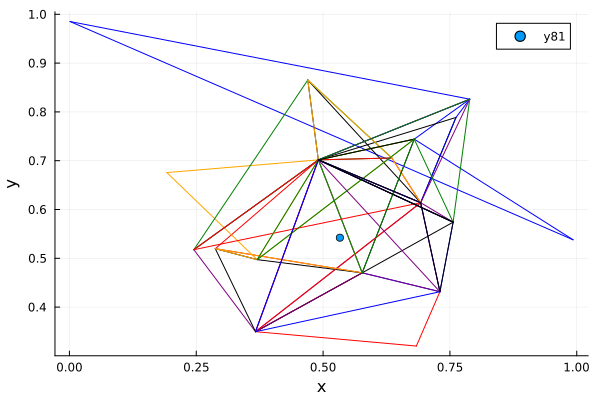

In [18]:
plot1 = Plots.plot(xlabel="x",ylabel="y")

cols = [:green,:blue,:black,:red,:orange,:purple]

for (j,simp) in enumerate(potentialSimplices)
    J = j%6 + 1
    for i in 1:4
        if i == 4
            Plots.plot!([simp[i,1],simp[1,1]],[simp[i,2],simp[1,2]],color=cols[J],label="")
            break
        end
        Plots.plot!([simp[i,1],simp[i+1,1]],[simp[i,2],simp[i+1,2]],color=cols[J],label="")
    end
end

Plots.scatter!([newPoint[1]],[newPoint[2]])

plot1